In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import illustris_python as il
import pickle

In [2]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
snapnum=40

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200", "Group_R_TopHat200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [7]:
mfof = np.log10(halos["GroupMass"]*1e10)

In [8]:
mvir_lin = halos["Group_M_TopHat200"]
mfof_lin = halos["GroupMass"]

In [9]:
rvir = halos["Group_R_TopHat200"]/1e3

In [10]:
sfrs = halos["GroupSFR"]

Text(0.5, 1.0, 'logM10-15')

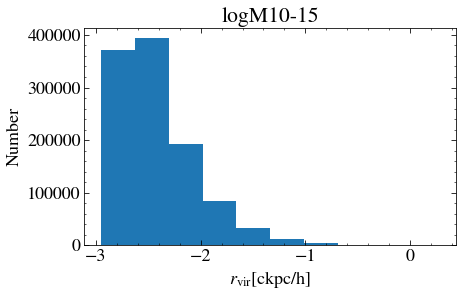

In [11]:
logMmin = 10
logMmax = 15
mask = (mvir>logMmin) & (mvir < logMmax) & (sfrs>0)
plt.hist(np.log(rvir[mask]))
plt.xlabel("$r_{\mathrm{vir}}$[ckpc/h]")
plt.ylabel("Number")
plt.title(f"logM{logMmin}-{logMmax}")

In [12]:
mean = np.mean(rvir[mask])
print(mean)
sfr_weighted_mean = np.sum(sfrs[mask]*rvir[mask])/np.sum(sfrs[mask])
print(sfr_weighted_mean)

0.09632475
0.28403476


In [41]:
def lognormal(r, sigma, R):
    d = R*2
    fr = np.exp(-(np.log(r/d))**2/(2*sigma**2))/(r*sigma*np.sqrt(2*np.pi))
    return fr

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


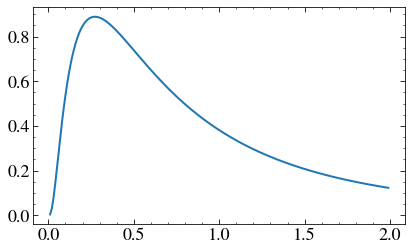

In [48]:
y1 = lognormal(ds, sigma=1,R=0.37)
plt.plot(ds,y1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'PDF')

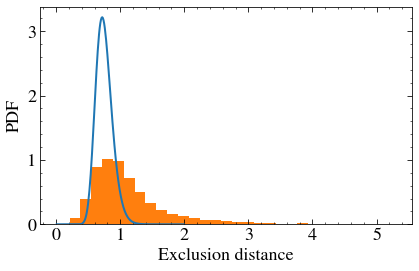

In [73]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.17,R=0.37)
plt.plot(ds,y)
plt.hist(2*rvir[mask], weights=sfrs[mask], density=True, bins=30)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

In [ ]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.17,R=0.37)
plt.plot(ds,y)
plt.hist(2*rvir[mask], weights=sfrs[mask], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

(array([1.093229e+06, 1.980000e+02, 2.800000e+01, 1.300000e+01,
        1.200000e+01, 4.000000e+00, 2.000000e+00, 1.000000e+00,
        1.000000e+00, 1.000000e+00]),
 array([4.3747360e-11, 7.3670999e-05, 1.4734195e-04, 2.2101292e-04,
        2.9468388e-04, 3.6835484e-04, 4.4202580e-04, 5.1569677e-04,
        5.8936770e-04, 6.6303869e-04, 7.3670963e-04], dtype=float32),
 <BarContainer object of 10 artists>)

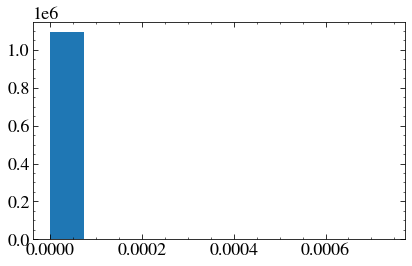

In [15]:
plt.hist(sfrs[mask]*rvir[mask]/np.sum(sfrs[mask]))

### logM12-12.5

In [16]:
logMmin = 12
logMmax = 12.5
mask12 = (mvir>logMmin) & (mvir < logMmax) & (sfrs>0)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'PDF')

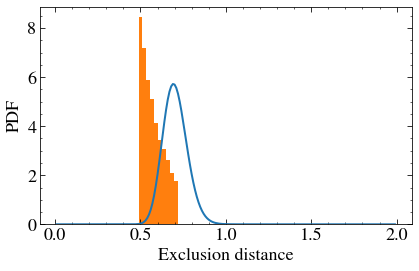

In [17]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)
plt.plot(ds,y)
plt.hist(2*rvir[mask12], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


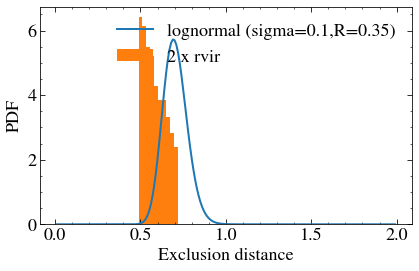

In [77]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)
plt.plot(ds,y, label="lognormal (sigma=0.1,R=0.35)")
plt.hist(2*rvir[mask12], weights=sfrs[mask12], density=True, label="2 x rvir")
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")
plt.legend()

### FOF vs virial

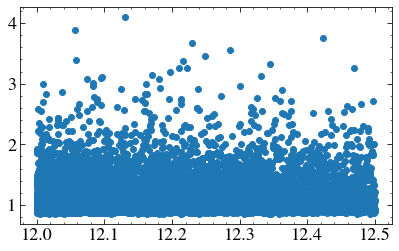

In [18]:
mass_ratio = mfof_lin[mask12]/mvir_lin[mask12]
plt.scatter(mvir[mask12], mass_ratio)

In [35]:
r_ratio = mass_ratio**(1/3)

(array([1.3909e+04, 1.9640e+03, 7.0300e+02, 2.4400e+02, 9.2000e+01,
        4.9000e+01, 1.8000e+01, 8.0000e+00, 4.0000e+00, 2.0000e+00]),
 array([0.8443289, 1.1704141, 1.4964993, 1.8225844, 2.1486697, 2.4747548,
        2.80084  , 3.1269252, 3.4530103, 3.7790956, 4.1051807],
       dtype=float32),
 <BarContainer object of 10 artists>)

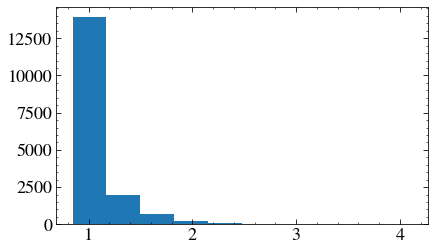

In [19]:
plt.hist(mass_ratio)

In [32]:
import itertools

def sum_combinations(lst):
    sums = [x + y for x, y in itertools.combinations(lst, 2)]
    #sums.append(2*lst)
    return sums


In [36]:
distances = sum_combinations(rvir[mask12]*mass_ratio)

(array([3.73830440e+00, 1.11196006e+00, 1.80031574e-01, 6.00105795e-02,
        3.53003194e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 3.53003409e-03]),
 array([0.44858298, 0.6447627 , 0.84094244, 1.0371222 , 1.2333019 ,
        1.4294816 , 1.6256614 , 1.8218411 , 2.0180209 , 2.2142007 ,
        2.4103804 ], dtype=float32),
 <BarContainer object of 10 artists>)

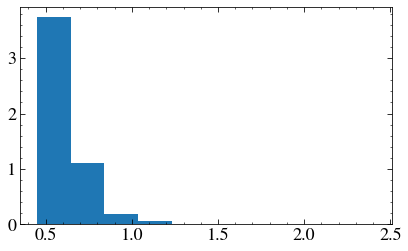

In [37]:
plt.hist(distances[::100000], density=True)


In [ ]:
ds = np.arange(0,2, 0.01)
y = lognormal(ds, sigma=0.1,R=0.35)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'PDF')

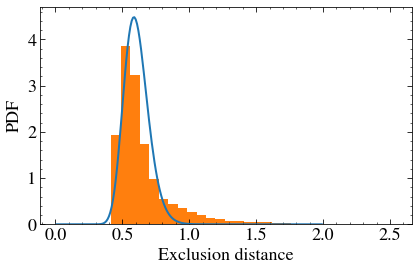

In [85]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(2*rvir[mask12]*mass_ratio, weights=sfrs[mask12], density=True, bins=30)
#plt.hist(distances[::100000], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'PDF')

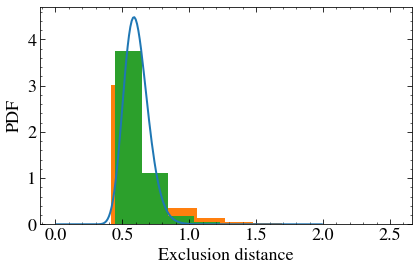

In [79]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(2*rvir[mask12]*mass_ratio, weights=sfrs[mask12], density=True)
plt.hist(distances[::100000], density=True)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log
  This is separate from the ipykernel package so we can avoid doing imports until
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


Text(0, 0.5, 'PDF')

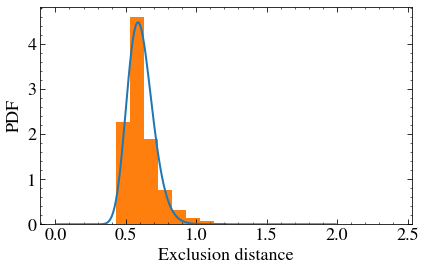

In [83]:
y = lognormal(ds, sigma=0.15,R=0.3)
plt.plot(ds,y)
plt.hist(distances[::100], density=True, bins=20)
plt.xlabel("Exclusion distance")
plt.ylabel("PDF")